# Confidence Intervals

In [1]:
from datascience import *
%matplotlib inline

import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import numpy as np

import warnings
warnings.simplefilter("ignore")

## Percentiles ##

In [2]:
# Manually compute the 55th percentile.
x = make_array(43, 20, 51, 7, 28, 34)

In [3]:
x

array([43, 20, 51,  7, 28, 34])

In [4]:
# Step 1. Sort the data
np.sort(x)

array([ 7, 20, 28, 34, 43, 51])

In [5]:
x

array([43, 20, 51,  7, 28, 34])

In [ ]:
# Step 2. Figure out where 55th percentile would be.

In [6]:
np.arange(1, 7)/6

array([ 0.16666667,  0.33333333,  0.5       ,  0.66666667,  0.83333333,
        1.        ])

In [7]:
np.arange(1, 7)/6 >= 55/100

array([False, False, False,  True,  True,  True], dtype=bool)

In [8]:
np.sort(x).item(3)

34

In [9]:
# Alternatively: One line of code
percentile(55, x)

34

In [10]:
x

array([43, 20, 51,  7, 28, 34])

## Discussion Question

In [12]:
s = make_array(1, 5, 7, 3, 9)
s

array([1, 5, 7, 3, 9])

In [21]:
percentile(100, s)

9

In [16]:
percentile(39, s)

3

In [19]:
percentile(41, s)

5

In [20]:
percentile(50, s) == 5

True

## Inference: Estimation

In [23]:
sf = Table.read_table('san_francisco_2019.csv')
sf.sample(3)

Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
Public Protection,Police,"Budget, Admn & Stats Analysis",Administrative Analyst,83061,0,38367,121428
Public Protection,Fire Department,Fire Services,"Battalion Chief, Fire Suppress",231247,80894,69714,381855
Public Protection,Fire Department,Fire Services,Firefighter,148937,11666,47916,208518


In [24]:
# Who made the most money
sf.sort('Total Compensation', descending=True).show(5)

Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
General Administration & Finance,Retirement Services,Administrative & Mgmt (Unrep),Chief Investment Officer,577633,0,146398,724031
General Administration & Finance,Retirement Services,Unassigned,Managing Director,483072,0,134879,617951
General Administration & Finance,Retirement Services,Unassigned,Managing Director,482649,0,134905,617554
General Administration & Finance,Retirement Services,Unassigned,Managing Director,451507,0,120276,571784
General Administration & Finance,Retirement Services,Unassigned,Managing Director,449378,0,120857,570235


In [25]:
# Who made the least money
sf.sort('Total Compensation', descending=False).show(5)

Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
Public Protection,Adult Probation,Probation & Parole,Deputy Probation Officer,0,0,0,0
Public Protection,Fire Department,"Clerical, Secretarial & Steno",Senior Clerk Typist,0,0,0,0
Public Protection,Juvenile Court,Correction & Detention,"Counselor, Juvenile Hall PERS",0,0,0,0
Public Protection,Police,"Clerical, Secretarial & Steno",Clerk Typist,0,0,0,0
Public Protection,Sheriff,Correction & Detention,Deputy Sheriff,0,0,0,0


In [29]:
# $15/hr, 20 hr/wk, 50 weeks

min_salary = 15 * 20 * 50
sf = sf.where('Salary', are.above(min_salary))
sf.sort('Total Compensation', descending=False).show(5)

Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
"Public Works, Transportation & Commerce",Municipal Transportation Agcy,Sub-Professional Engineering,"StdntDsgnTrain1, Arch/Eng/Plng",15578,0,41,15619
Public Protection,Trial Courts,Untitled,Superior Court Judge,15414,0,224,15637
Culture & Recreation,Recreation And Park Commission,Recreation,Recreation Coordinator,15016,0,1180,16196
"Public Works, Transportation & Commerce",Municipal Transportation Agcy,Protection & Apprehension,School Crossing Guard,15053,0,1168,16221
Human Welfare & Neighborhood Development,Human Services,Public Service Aide,Public Service Trainee,15008,0,1230,16238


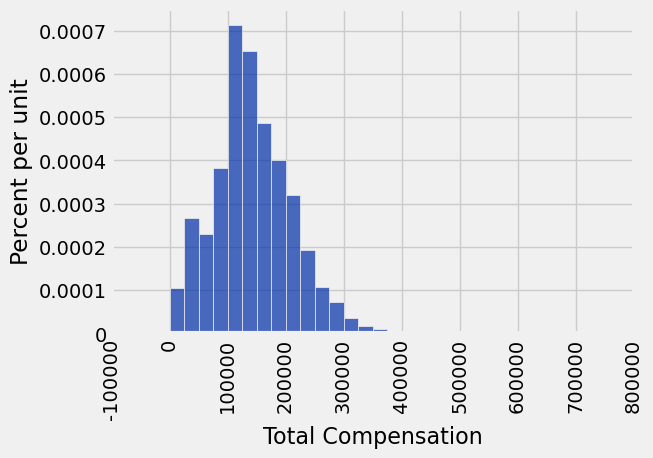

In [32]:
# Population Distribution

sf_bins = np.arange(0, 726000, 25000)
sf.hist('Total Compensation', bins=sf_bins)

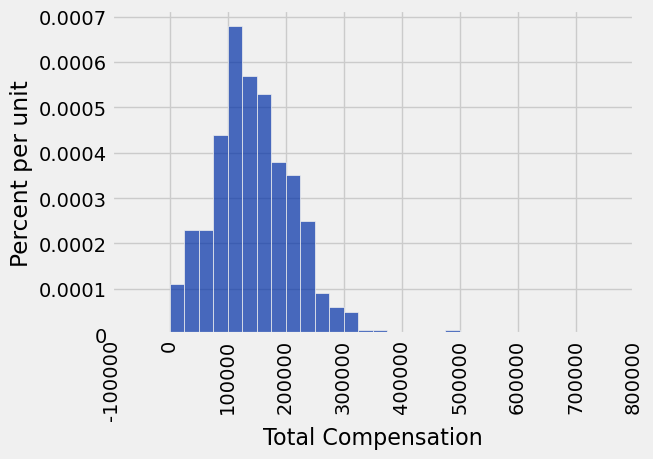

In [38]:
# An Empirical Distribution

our_sample = sf.sample(400, with_replacement=False)
our_sample.hist('Total Compensation', bins=sf_bins)

In [39]:
# Parameter: Median Total Compensation 

pop_median = percentile(50, sf.column('Total Compensation'))  # 37,000+ people
pop_median

135747.0

In [71]:
# Estimate: Median of a Sample

percentile(50, our_sample.column('Total Compensation')) # 400 people

139708.0

## Variability of the Estimate

In [41]:
def generate_sample_median(samp_size):
    new_sample = sf.sample(samp_size, with_replacement=False)
    return percentile(50, new_sample.column('Total Compensation'))

In [61]:
generate_sample_median(400)

137804.0

## Quantifying Uncertainty

In [68]:
sample_medians = make_array()

for i in np.arange(1000):
    new_median = generate_sample_median(400)
    sample_medians = np.append(sample_medians, new_median)

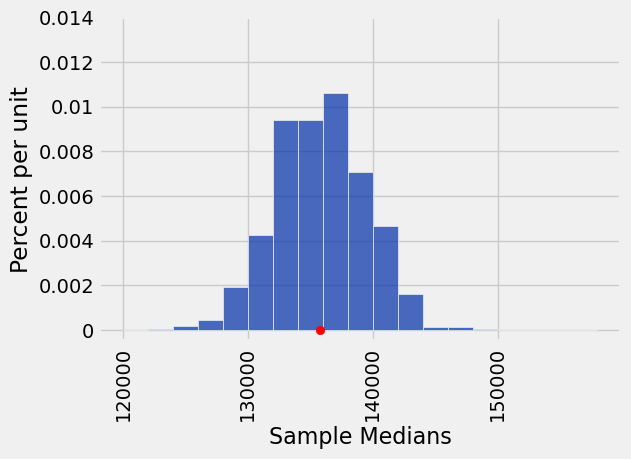

In [69]:
med_bins = np.arange(120000, 160000, 2000)
Table().with_column('Sample Medians', sample_medians).hist(bins=med_bins)

plots.ylim(-0.000005, 0.00014)
plots.scatter(pop_median, 0, color='red');

In [70]:
print('Less than 2.5% of estimates are more than', pop_median - percentile(2.5, sample_medians), 'lower than', pop_median)
print('Less than 2.5% of estimates are more than', percentile(97.5, sample_medians) - pop_median, 'higher than', pop_median)

Less than 2.5% of estimates are more than 6878.0 lower than 135747.0
Less than 2.5% of estimates are more than 6604.0 higher than 135747.0


## Bootstrap

Sample randomly
 - from the original sample
 - with replacement
 - the same number of times as the original sample size

140501.0

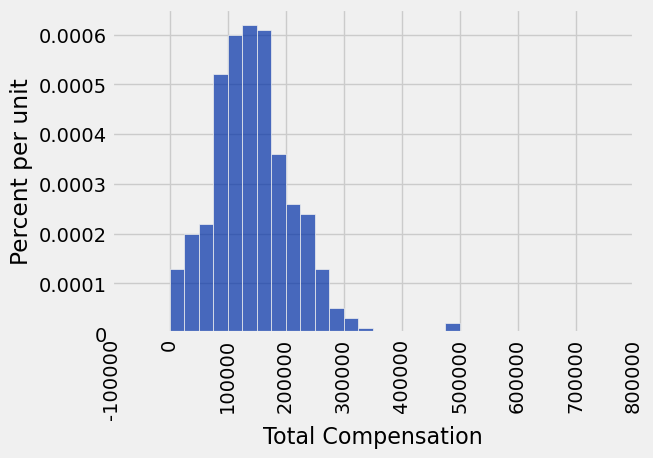

In [72]:
# Default behavior of t.sample():
# at random with replacement,
# the same number of times as the number of rows in t

bootstrap_sample = our_sample.sample()
bootstrap_sample.hist('Total Compensation', bins=sf_bins)
percentile(50, bootstrap_sample.column('Total Compensation'))

In [73]:
def one_bootstrap_median():
    # draw the bootstrap sample
    resample = our_sample.sample()
    # return the median total compensation in the bootstrap sample
    return percentile(50, resample.column('Total Compensation'))

In [93]:
one_bootstrap_median()

135380.0

In [94]:
# Generate the medians of 1000 bootstrap samples
num_repetitions = 1000
bstrap_medians = make_array()
for i in np.arange(num_repetitions):
    bstrap_medians = np.append(bstrap_medians, one_bootstrap_median())

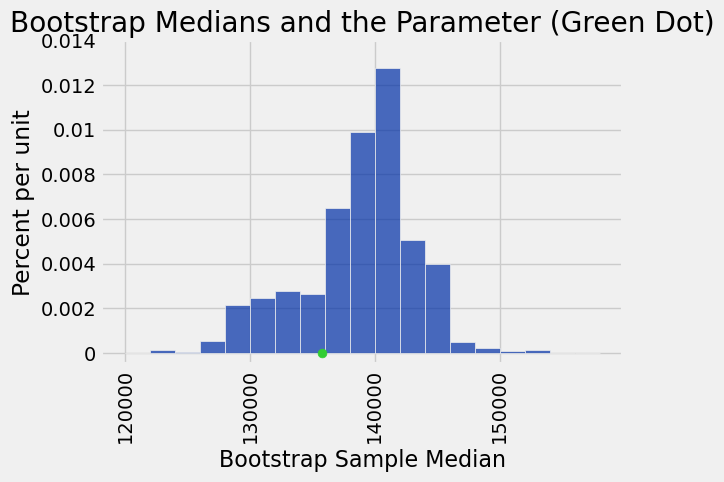

In [95]:
resampled_medians = Table().with_column('Bootstrap Sample Median', bstrap_medians)
median_bins=np.arange(120000, 160000, 2000)
resampled_medians.hist(bins = median_bins)

# Plotting parameters; you can ignore this code
parameter_green = '#32CD32'
plots.ylim(-0.000005, 0.00014)
plots.scatter(pop_median, 0, color=parameter_green, s=40, zorder=2)
plots.title('Bootstrap Medians and the Parameter (Green Dot)');

## Percentile Method: Middle 95% of the Bootstrap Estimates 

In [97]:
left = percentile(2.5, bstrap_medians)
right = percentile(97.5, bstrap_medians)

make_array(left, right)  # The middle 95% of medians of bootstrap resamples

array([ 128909.,  145220.])

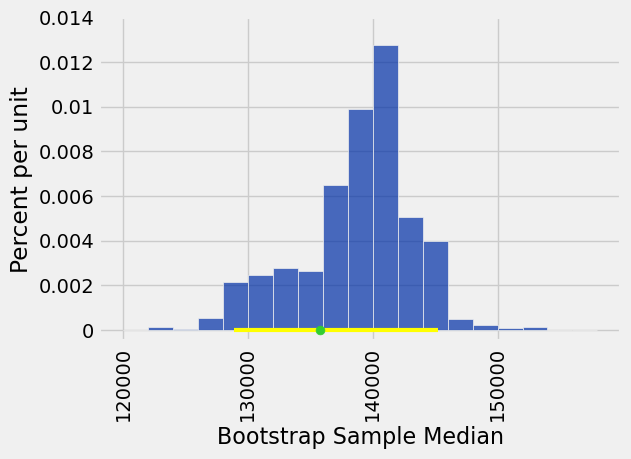

In [98]:
resampled_medians.hist(bins = median_bins)

# Plotting parameters; you can ignore this code
plots.ylim(-0.000005, 0.00014)
plots.plot(make_array(left, right), make_array(0, 0), color='yellow', lw=3, zorder=1)
plots.scatter(pop_median, 0, color=parameter_green, s=40, zorder=2);